# Imports

In [1]:
import os
import random
import shutil
import xml.etree.ElementTree as ET
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import yaml
from sklearn.model_selection import train_test_split

# Dataset Paths

In [2]:
DATASET_DIR = Path("/kaggle/input/datasets/andrewmvd/road-sign-detection")

ANNOTATIONS_DIR = Path("/kaggle/input/datasets/andrewmvd/road-sign-detection/annotations")
IMAGES_DIR = Path("/kaggle/input/datasets/andrewmvd/road-sign-detection/images")

print("Images exists:", IMAGES_DIR.exists())
print("Annotations exists:", ANNOTATIONS_DIR.exists())

Images exists: True
Annotations exists: True


In [3]:
print("Dataset contents:")

for item in DATASET_DIR.iterdir():
    print(item)

Dataset contents:
/kaggle/input/datasets/andrewmvd/road-sign-detection/annotations
/kaggle/input/datasets/andrewmvd/road-sign-detection/images


In [4]:
image_files = [
    f for f in IMAGES_DIR.iterdir()
    if f.suffix.lower() in [".jpg", ".jpeg", ".png"]
]

xml_files = list(ANNOTATIONS_DIR.glob("*.xml"))

print("Number of images:", len(image_files))
print("Number of annotations:", len(xml_files))

Number of images: 877
Number of annotations: 877


# extract classes names from XML

In [5]:
classes = set()

for xml_file in xml_files:
    tree = ET.parse(xml_file)
    root = tree.getroot()

    for obj in root.findall("object"):
        class_name = obj.find("name").text
        classes.add(class_name)

classes = sorted(classes)

print("Classes:")
for i, class_name in enumerate(classes):
    print(i, "->", class_name)

print("Number of classes:", len(classes))

Classes:
0 -> crosswalk
1 -> speedlimit
2 -> stop
3 -> trafficlight
Number of classes: 4


# Random Image

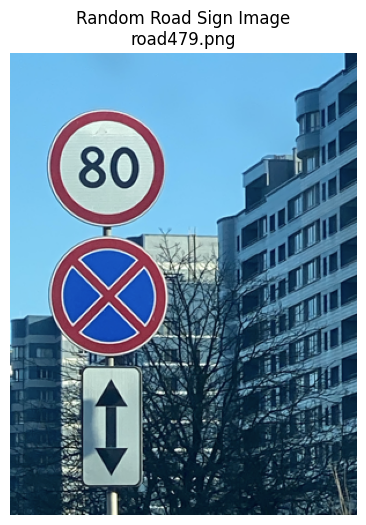

In [6]:
random_image = random.choice(image_files)

image = cv2.imread(str(random_image))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(image)
plt.axis("off")
plt.title(f"Random Road Sign Image\n{random_image.name}")
plt.show()

In [7]:
image = cv2.imread(str(random_image))

height, width, channels = image.shape

print("Image:", random_image.name)
print("Width:", width)
print("Height:", height)
print("Channels:", channels)

Image: road479.png
Width: 300
Height: 400
Channels: 3


In [8]:
def show_image_with_boxes(image_path, annotation_path):

    # Read image
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Read XML
    tree = ET.parse(annotation_path)
    root = tree.getroot()

    # Draw every object
    for obj in root.findall("object"):

        class_name = obj.find("name").text

        bbox = obj.find("bndbox")

        xmin = int(float(bbox.find("xmin").text))
        ymin = int(float(bbox.find("ymin").text))
        xmax = int(float(bbox.find("xmax").text))
        ymax = int(float(bbox.find("ymax").text))

        # Bounding box
        cv2.rectangle(
            image,
            (xmin, ymin),
            (xmax, ymax),
            (255, 0, 0),
            2
        )

        # Class name
        cv2.putText(
            image,
            class_name,
            (xmin, max(ymin - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 0, 0),
            2
        )

    # Display
    plt.figure(figsize=(12, 8))
    plt.imshow(image)
    plt.axis("off")
    plt.title("Road Signs - Ground Truth Bounding Boxes")
    plt.show()

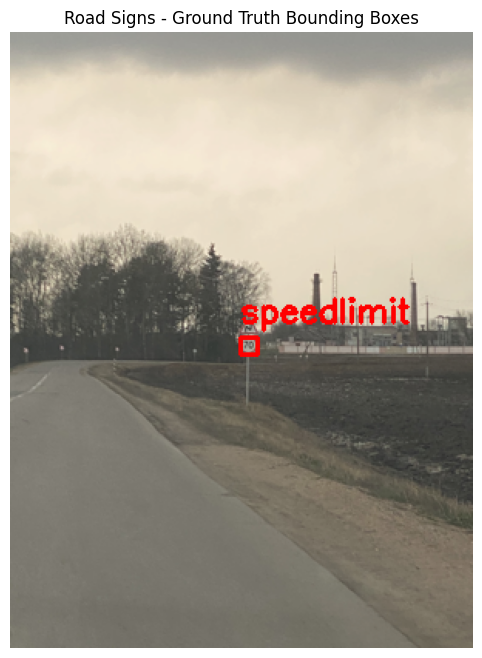

In [9]:
random_image = random.choice(image_files)

annotation_file = ANNOTATIONS_DIR / f"{random_image.stem}.xml"

if annotation_file.exists():

    show_image_with_boxes(
        random_image,
        annotation_file
    )

else:
    print("Annotation not found:", annotation_file)

# Multiple Images

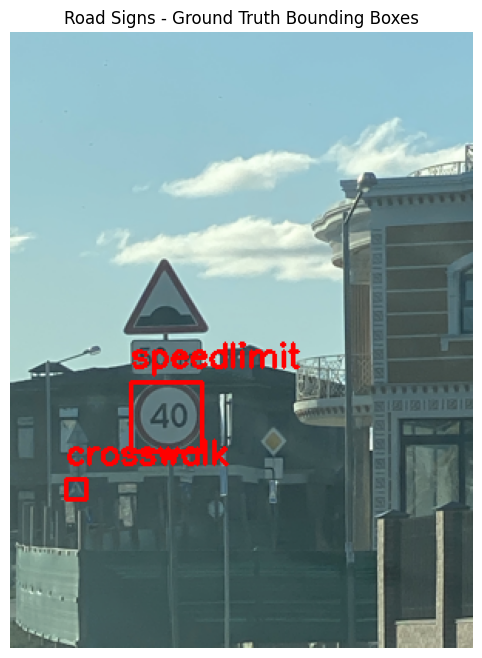

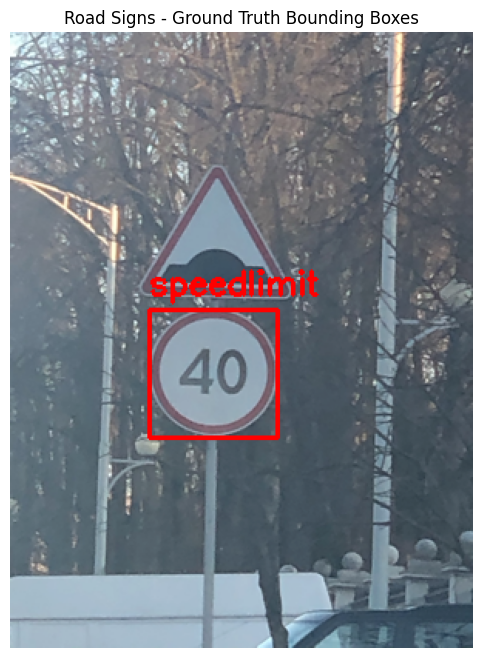

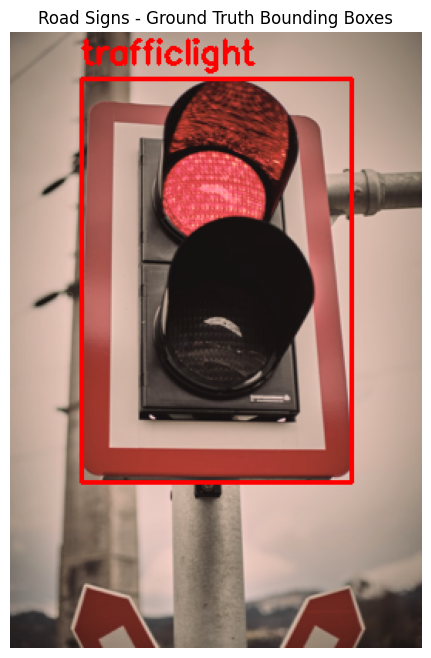

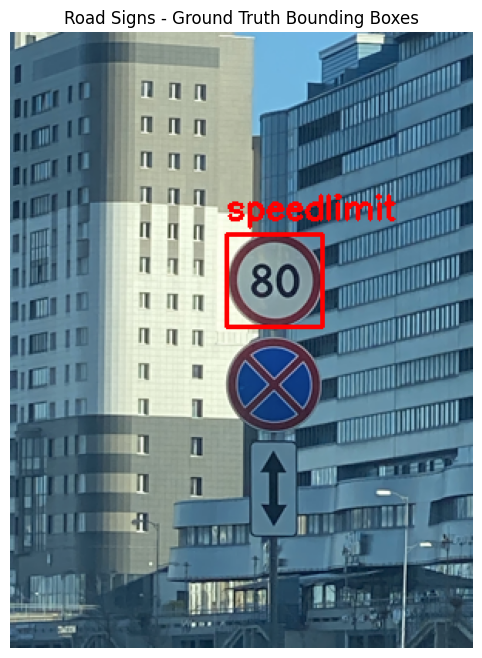

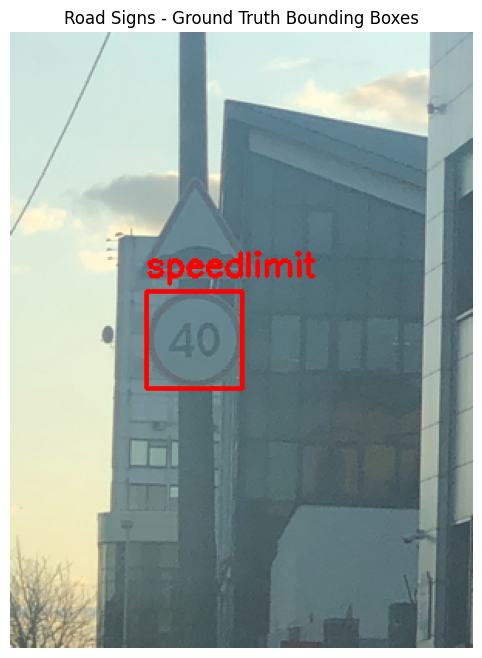

In [10]:
sample_images = random.sample(
    image_files,
    min(5, len(image_files))
)

for image_path in sample_images:

    annotation_path = ANNOTATIONS_DIR / f"{image_path.stem}.xml"

    if annotation_path.exists():

        show_image_with_boxes(
            image_path,
            annotation_path
        )

# Objects per Class

In [11]:
class_counts = {class_name: 0 for class_name in classes}

for xml_file in xml_files:

    tree = ET.parse(xml_file)
    root = tree.getroot()

    for obj in root.findall("object"):

        class_name = obj.find("name").text

        if class_name in class_counts:
            class_counts[class_name] += 1

print("Object counts:")

for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

Object counts:
crosswalk: 200
speedlimit: 783
stop: 91
trafficlight: 170


# Class Distribution

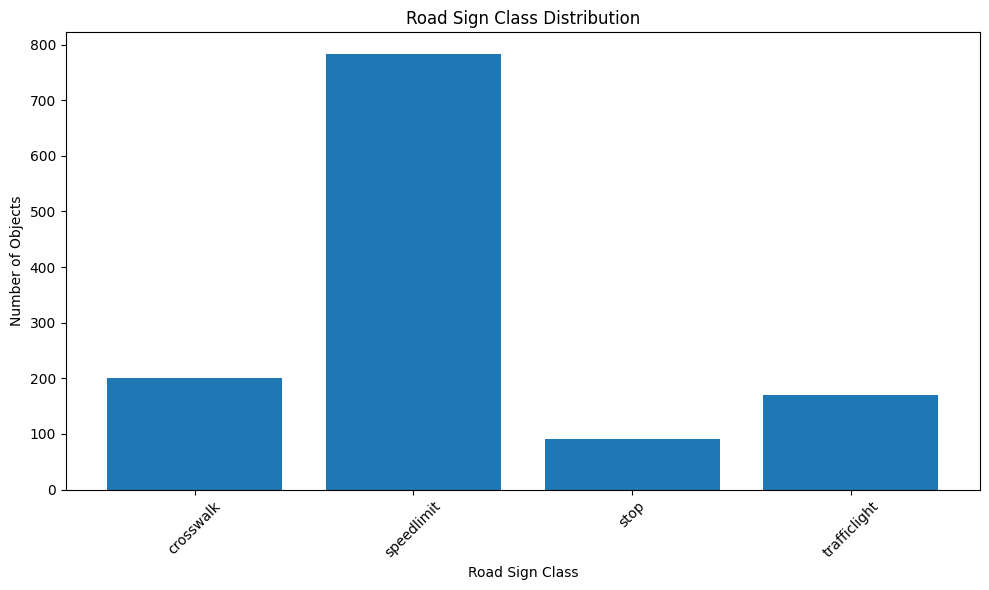

In [12]:
plt.figure(figsize=(10, 6))

plt.bar(
    class_counts.keys(),
    class_counts.values()
)

plt.xlabel("Road Sign Class")
plt.ylabel("Number of Objects")
plt.title("Road Sign Class Distribution")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# Train / Validation / Test Split

In [13]:
train_files, temp_files = train_test_split(
    image_files,
    test_size=0.30,
    random_state=42
)

val_files, test_files = train_test_split(
    temp_files,
    test_size=0.50,
    random_state=42
)

print("Train:", len(train_files))
print("Validation:", len(val_files))
print("Test:", len(test_files))

Train: 613
Validation: 132
Test: 132


# Create YOLO Dataset Structure

In [14]:
YOLO_DATASET = Path("/kaggle/working/road_sign_yolo")

for split in ["train", "val", "test"]:

    (YOLO_DATASET / split / "images").mkdir(
        parents=True,
        exist_ok=True
    )

    (YOLO_DATASET / split / "labels").mkdir(
        parents=True,
        exist_ok=True
    )

print("YOLO dataset structure created.")

YOLO dataset structure created.


## XML → YOLO Conversion Function

In [15]:
def convert_xml_to_yolo(
    xml_file,
    output_label_file,
    class_to_id
):

    tree = ET.parse(xml_file)
    root = tree.getroot()

    size = root.find("size")

    image_width = int(size.find("width").text)
    image_height = int(size.find("height").text)

    yolo_annotations = []

    for obj in root.findall("object"):

        class_name = obj.find("name").text

        if class_name not in class_to_id:
            continue

        class_id = class_to_id[class_name]

        bbox = obj.find("bndbox")

        xmin = float(bbox.find("xmin").text)
        ymin = float(bbox.find("ymin").text)
        xmax = float(bbox.find("xmax").text)
        ymax = float(bbox.find("ymax").text)

        # Convert to YOLO format

        x_center = ((xmin + xmax) / 2) / image_width
        y_center = ((ymin + ymax) / 2) / image_height

        width = (xmax - xmin) / image_width
        height = (ymax - ymin) / image_height

        yolo_annotations.append(
            f"{class_id} "
            f"{x_center:.6f} "
            f"{y_center:.6f} "
            f"{width:.6f} "
            f"{height:.6f}"
        )

    with open(output_label_file, "w") as f:

        f.write("\n".join(yolo_annotations))

In [17]:
class_to_id = {
    class_name: i
    for i, class_name in enumerate(classes)
}

print(class_to_id)
def prepare_split(files, split_name):

    image_output_dir = (
        YOLO_DATASET / split_name / "images"
    )

    label_output_dir = (
        YOLO_DATASET / split_name / "labels"
    )

    for image_file in files:

        # Copy image
        shutil.copy2(
            image_file,
            image_output_dir / image_file.name
        )

        # Corresponding XML
        xml_file = (
            ANNOTATIONS_DIR /
            f"{image_file.stem}.xml"
        )

        if not xml_file.exists():

            print(
                "Missing annotation:",
                image_file.name
            )

            continue

        # YOLO label path
        label_file = (
            label_output_dir /
            f"{image_file.stem}.txt"
        )

        # Convert XML → YOLO
        convert_xml_to_yolo(
            xml_file,
            label_file,
            class_to_id
        )


prepare_split(train_files, "train")
prepare_split(val_files, "val")
prepare_split(test_files, "test")

print("Dataset conversion completed.")

{'crosswalk': 0, 'speedlimit': 1, 'stop': 2, 'trafficlight': 3}
Dataset conversion completed.


In [18]:
train_labels = list(
    (YOLO_DATASET / "train" / "labels").glob("*.txt")
)

print("Number of YOLO training labels:", len(train_labels))

if train_labels:

    print("\nExample label:")
    print(train_labels[0].read_text())

Number of YOLO training labels: 613

Example label:
1 0.410000 0.343750 0.080000 0.062500


In [19]:
data_yaml = {

    "path": str(YOLO_DATASET),

    "train": "train/images",

    "val": "val/images",

    "test": "test/images",

    "nc": len(classes),

    "names": classes
}

yaml_path = Path("/kaggle/working/data.yaml")

with open(yaml_path, "w") as f:

    yaml.dump(
        data_yaml,
        f,
        sort_keys=False
    )

print(yaml_path.read_text())

path: /kaggle/working/road_sign_yolo
train: train/images
val: val/images
test: test/images
nc: 4
names:
- crosswalk
- speedlimit
- stop
- trafficlight



In [20]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 433.9 kB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 14.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.4/75.4 kB 5.3 MB/s eta 0:00:00


In [21]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


In [22]:
model = YOLO("yolov8n.pt")

In [23]:
model.info()

YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs


(129, 3157200, 0, 8.8550912)

In [24]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    device = 0
    print("Using GPU")
else:
    device = "cpu"
    print("Using CPU")

CUDA available: True
Using GPU


In [25]:
results = model.train(
    data=str(yaml_path),
    epochs=30,
    imgsz=640,
    batch=16,
    device=device,
    workers=2,
    project="road_sign_detection",
    name="yolov8_road_sign"
)

Ultralytics 8.4.145 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_road_sign, nbs=64, nms=None, opset=None, op

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(


       2/30       2.6G     0.8214       1.55     0.9321          7        640: 100% ━━━━━━━━━━━━ 39/39 7.4it/s 5.3s0.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 5.4it/s 0.9s0.3s
                   all        132        180       0.75       0.44      0.769      0.607

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/30       2.6G     0.7842        1.3      0.951         16        640: 100% ━━━━━━━━━━━━ 39/39 7.3it/s 5.3s0.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 6.0it/s 0.8s0.3s
                   all        132        180      0.729      0.827      0.834      0.642

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       4/30       2.6G     0.8083      1.189     0.9497         12        640: 100% ━━━━━━━━━━━━ 39/39 7.4it/s 5.3s0.3s
                 Class     Images  Instances  

In [26]:
metrics = model.val(
    data=str(yaml_path),
    device=device
)

Ultralytics 8.4.145 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 72 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4060.8±980.5 MB/s, size: 322.5 KB)
val: Scanning /kaggle/working/road_sign_yolo/val/labels.cache... 132 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 132/132 55.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 4.7it/s 1.9s0.1ss
                   all        132        180      0.951      0.946       0.96      0.828
             crosswalk         26         29      0.899      0.931      0.971        0.8
            speedlimit         98        113      0.992          1      0.995      0.899
                  stop         16         16      0.965          1      0.995       0.95
          trafficlight         15         22      0.949      0.853      0.881      0.664
Speed: 2.3ms preprocess, 4.6ms i

In [27]:
best_model_path = Path(
    "road_sign_detection/yolov8_road_sign/weights/best.pt"
)

print("Best model exists:", best_model_path.exists())

Best model exists: False


In [28]:
test_image = random.choice(test_files)

print(test_image)

/kaggle/input/datasets/andrewmvd/road-sign-detection/images/road248.png


In [29]:
prediction = model.predict(
    source=str(test_image),
    conf=0.25,
    device=device
)


image 1/1 /kaggle/input/datasets/andrewmvd/road-sign-detection/images/road248.png: 640x480 2 speedlimits, 5.9ms
Speed: 1.6ms preprocess, 5.9ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 480)


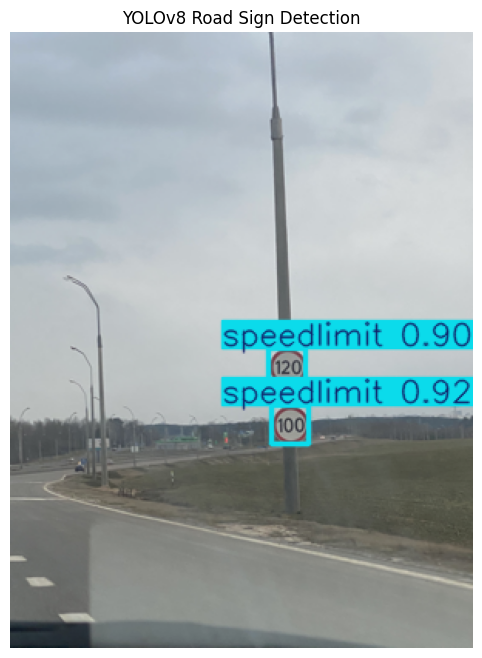

In [30]:
result = prediction[0]

annotated_image = result.plot()

annotated_image = cv2.cvtColor(
    annotated_image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(12, 8))

plt.imshow(annotated_image)

plt.axis("off")

plt.title("YOLOv8 Road Sign Detection")

plt.show()

In [31]:
for box in result.boxes:

    class_id = int(box.cls[0])

    confidence = float(box.conf[0])

    class_name = model.names[class_id]

    print(
        f"Class: {class_name} | "
        f"Confidence: {confidence:.2%}"
    )

Class: speedlimit | Confidence: 91.79%
Class: speedlimit | Confidence: 90.05%


In [32]:
from pathlib import Path

best_models = list(Path("/kaggle/working").rglob("best.pt"))

print("Found best.pt files:")
for path in best_models:
    print(path)

Found best.pt files:
/kaggle/working/runs/detect/road_sign_detection/yolov8_road_sign/weights/best.pt
